# Estimation of Background Distribution Using Partially Permuted Proteins

In [1]:
# from Database import Database
# db = Database.load('../../pdb-database-mirror', compressed=False)
# db.estimate_background_distribution('background_estimation_set.json', {'k_mer_similarity_threshold':14, 'lr': 0.25, 'progress': True}, sub_sample=0.005, n_permutations=1)

In [2]:
import json
with open('test-background-distribution-samples.json', 'r') as file:
    data = json.load(file)
print(data)

[[21, 11118, 0.4607003630483677], [21, 10845, 0.6551013803117718], [21, 10845, 0.46655629986263847], [21, 11487, 0.46625659762427907], [21, 12499, 0.46337144751101444], [21, 11716, 0.4416705335538823], [21, 11858, 0.45926373985705304], [21, 11913, 0.4725927340766817], [21, 12505, 0.4399871208913225], [21, 11675, 0.48396857762191003], [21, 22286, 0.9415703138906006], [21, 12585, 0.4222742637908137], [21, 12383, 0.423731615355984], [21, 12544, 0.47107548125521237], [21, 11415, 0.47618347093238567], [21, 12932, 0.4621254749702738], [21, 11141, 0.4719242225694237], [21, 11298, 0.6542094353664276], [21, 12322, 0.47899649743013994], [21, 11605, 0.4415497976537396], [21, 22170, 0.4434617619571941], [21, 12513, 0.537481758728714], [21, 11666, 0.542159590698537], [21, 12666, 0.43819211232833744], [21, 12664, 0.43520632106852397], [21, 11089, 0.48104263176020157], [21, 11667, 0.4460024338744236], [21, 11740, 0.45894836778916337], [21, 11584, 0.46757617936744067], [21, 28891, 0.8733550756742086],

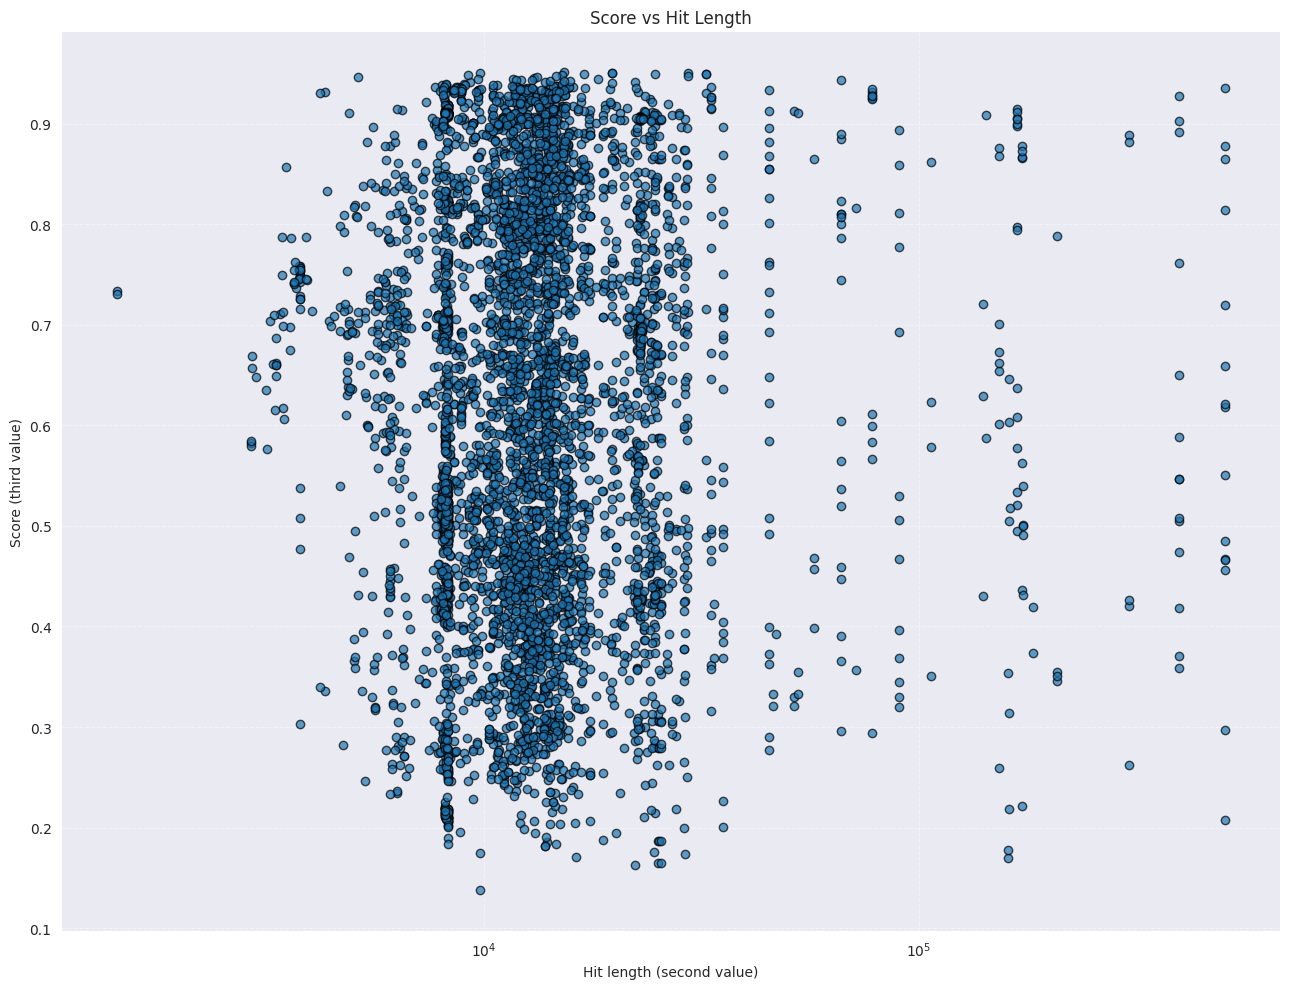

In [3]:
import matplotlib.pyplot as plt
# Extract hit lengths and scores
hit_lengths = [row[1] for row in data]
scores = [row[2] for row in data]

# Basic scatter plot
plt.figure(figsize=(13,10))
plt.scatter(hit_lengths, scores, alpha=0.7, edgecolor='k')
plt.xscale('log')              # optional: use log scale if hit lengths vary widely
plt.xlabel('Hit length (second value)')
plt.ylabel('Score (third value)')
plt.title('Score vs Hit Length')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

/tmp/ipykernel_32422/1067008977.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df.groupby(['query_bin', 'hit_bin'])['score'].median().unstack()


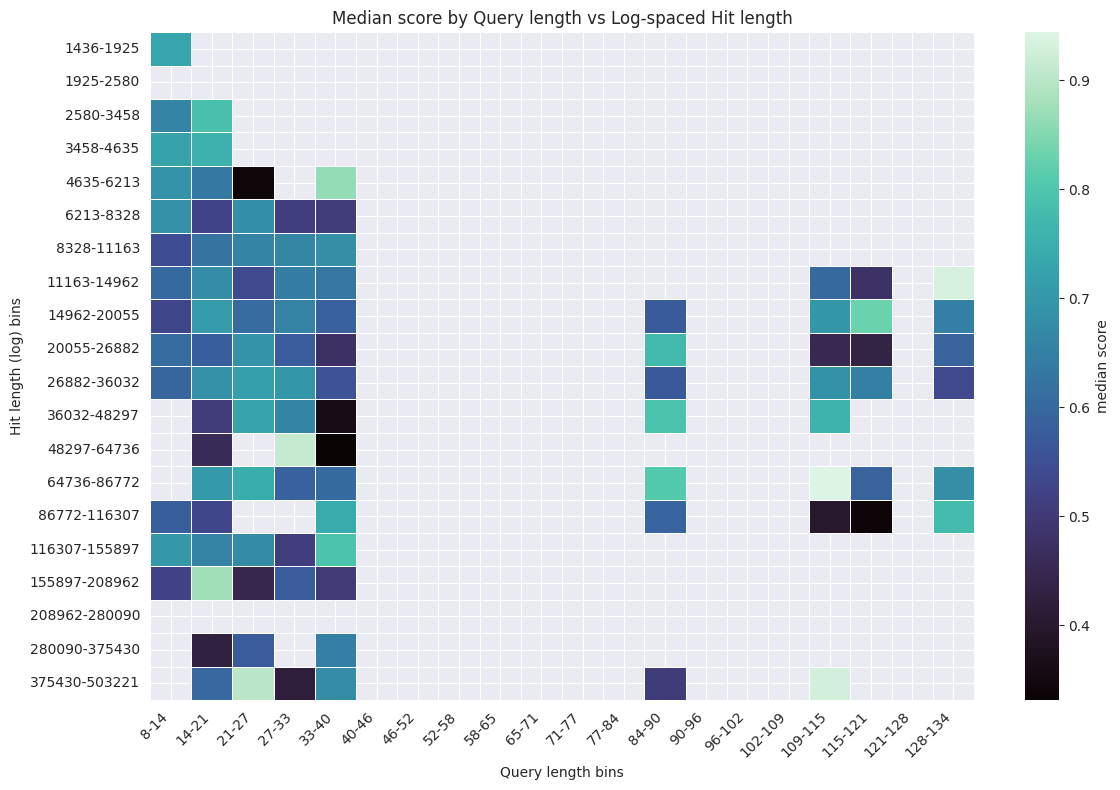

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns

# Create DataFrame
df = pd.DataFrame(data, columns=['query_len', 'hit_len', 'score'])

# Parameters
x_bins = 20             # bins for query_len (linear)
y_log_bins = 20         # bins for hit_len (log-spaced)

# Create linear bins for query_len
df['query_bin'] = pd.cut(df['query_len'], bins=x_bins)

# Create log-spaced bins for hit_len
# Ensure hit_len > 0
df = df[df['hit_len'] > 0].copy()
y_min, y_max = df['hit_len'].min(), df['hit_len'].max()
log_edges = np.logspace(np.log10(y_min), np.log10(y_max), num=y_log_bins + 1)
df['hit_bin'] = pd.cut(df['hit_len'], bins=log_edges)

# Aggregate (median score per bin pair)
pivot = df.groupby(['query_bin', 'hit_bin'])['score'].median().unstack()

# Prepare readable axis labels (use bin centers or ranges)
x_labels = [f"{interval.left:.0f}-{interval.right:.0f}" for interval in pivot.index]
y_labels = [f"{interval.left:.0f}-{interval.right:.0f}" for interval in pivot.columns]

plt.figure(figsize=(12, 8))
sns.heatmap(pivot.T, cmap='mako', cbar_kws={'label': 'median score'},
            linewidths=0.5, linecolor='white', square=False)

plt.xlabel('Query length bins')
plt.ylabel('Hit length (log) bins')
plt.title('Median score by Query length vs Log-spaced Hit length')

# Use the prepared labels; rotate for readability
plt.xticks(np.arange(len(x_labels)) + 0.5, x_labels, rotation=45, ha='right')
plt.yticks(np.arange(len(y_labels)) + 0.5, y_labels, rotation=0)
plt.tight_layout()
plt.show()

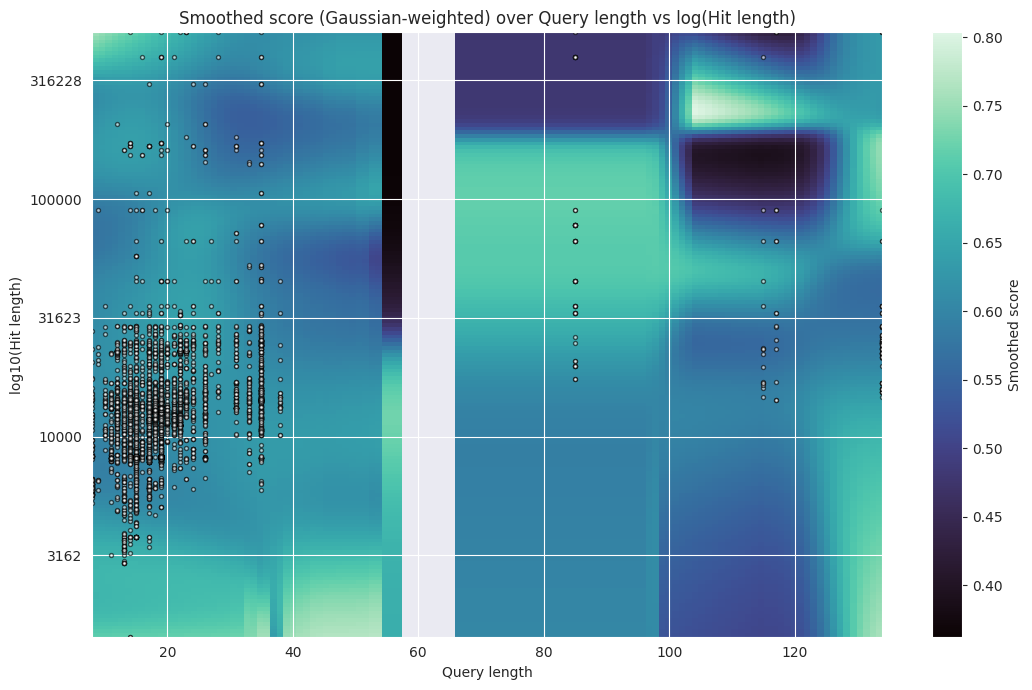

In [5]:
from scipy.spatial import cKDTree

# Transform hit_len to log space for binning/smoothing
df['log_hit'] = np.log10(df['hit_len'])

# Grid definition
nx, ny = 120, 160                       # increase for smoother map
q_min, q_max = df['query_len'].min(), df['query_len'].max()
l_min, l_max = df['log_hit'].min(), df['log_hit'].max()
q_grid = np.linspace(q_min, q_max, nx)
l_grid = np.linspace(l_min, l_max, ny)
Q, L = np.meshgrid(q_grid, l_grid)


# Prepare KD-tree for fast neighbor queries
pts = np.vstack([df['query_len'].values, df['log_hit'].values]).T
tree = cKDTree(pts)

# Smoothing parameters
bandwidth_q = max(1.0, (q_max - q_min) / 20.0)       # scale for query_len
bandwidth_l = max(0.1, (l_max - l_min) / 20.0)      # scale for log(hit_len)
bandwidth = np.array([bandwidth_q, bandwidth_l])

# Function: compute weighted local average score on grid using Gaussian weights
def gaussian_weights(dist_sq, bw):
    # dist_sq: squared Mahalanobis distance relative to bandwidth
    return np.exp(-0.5 * dist_sq)

scores_grid = np.full((ny, nx), np.nan)

# For each grid cell, query neighbors within 3*sigma ellipse and compute weighted mean
max_radius = 3.0
for i in range(ny):
    for j in range(nx):
        query_point = np.array([q_grid[j], l_grid[i]])
        # find neighbors within radius in scaled space
        # transform points by dividing by bandwidth to compute Euclidean radius
        scaled_query = query_point / bandwidth
        scaled_pts = pts / bandwidth
        idxs = tree.query_ball_point(query_point, r=max_radius * bandwidth.max(), p=2)
        if not idxs:
            continue
        neighbors = pts[idxs]
        dif = (neighbors - query_point) / bandwidth
        dist_sq = np.sum(dif**2, axis=1)
        w = gaussian_weights(dist_sq, bandwidth)
        if w.sum() > 0:
            scores_grid[i, j] = np.sum(w * df['score'].values[idxs]) / np.sum(w)

# Plot heatmap (x axis: query_len, y axis: hit_len as log scale)
plt.figure(figsize=(11, 7))
# Convert log axis back to hit_len tick labels
extent = [q_min, q_max, 10**l_min, 10**l_max]
# Use imshow with aspect='auto' and log y-axis
im = plt.imshow(scores_grid, origin='lower', aspect='auto',
                extent=[q_min, q_max, l_min, l_max], cmap='mako')
plt.colorbar(im, label='Smoothed score')
plt.xlabel('Query length')
plt.ylabel('log10(Hit length)')
plt.title('Smoothed score (Gaussian-weighted) over Query length vs log(Hit length)')
# Optionally overlay raw points
plt.scatter(df['query_len'], df['log_hit'], s=8, c='white', edgecolor='k', alpha=0.6)

# Improve ticks: show hit_len ticks in original scale on right y-axis
from matplotlib.ticker import FuncFormatter
ax = plt.gca()
def tick_to_hit(x, pos):
    return f"{10**x:.0f}"
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_formatter(FuncFormatter(tick_to_hit))
plt.tight_layout()
plt.show()

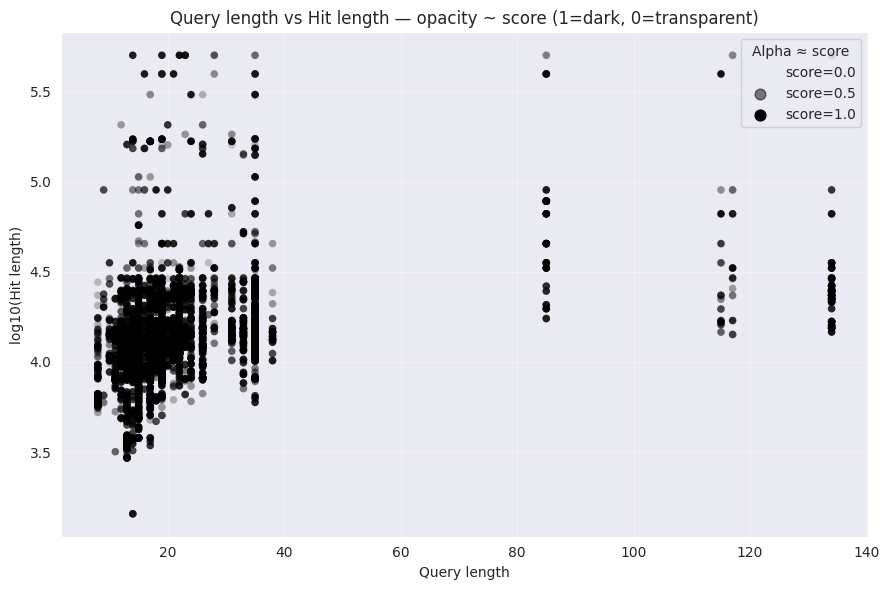

In [6]:
df = pd.DataFrame(data, columns=['query_len', 'hit_len', 'score'])
df = df[df['hit_len'] > 0].copy()

# If hit_len spans many orders of magnitude, use log scale for visual clarity
use_log_y = True

x = df['query_len'].values
y = np.log10(df['hit_len'].values) if use_log_y else df['hit_len'].values

# Map score (0..1) to alpha (0..1) where 1 -> opaque (dark), 0 -> transparent
alphas = np.clip(df['score'].values, 0.0, 1.0)

plt.figure(figsize=(9, 6))
# Choose marker color (black) and vary alpha per point
plt.scatter(x, y, c='black', alpha=alphas, s=30, edgecolors='none')

plt.xlabel('Query length')
plt.ylabel('log10(Hit length)' if use_log_y else 'Hit length')
plt.title('Query length vs Hit length — opacity ~ score (1=dark, 0=transparent)')
plt.grid(alpha=0.3)

# Optional: add a reference colorbar-like legend for alpha values
for v, xpos in [(0.0, 0.02), (0.5, 0.08), (1.0, 0.14)]:
    plt.scatter([], [], c='black', alpha=v, s=60, label=f'score={v:.1f}')
plt.legend(title='Alpha ≈ score', framealpha=0.9, loc='upper right')

plt.tight_layout()
plt.show()